# Student Details
## Name: Neeraj R Rugi
## SRN: PES2UG24CS311 

# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Building the Tumor Screening Dashboard

### Scenario

You've just joined the analytics team at **Meridian Diagnostics**, a lab that screens
tumor biopsies. Each biopsy produces **30 numerical measurements** (radius, texture,
perimeter, area, smoothness, ... in mean/SE/worst variants) — far too many to eyeball in
a spreadsheet. The lead pathologist has given you a blunt brief:

1. *"I can't look at 30 numbers per patient and see anything. I need to SEE the data."*
2. *"Before you throw away information, prove to me that these 30 measurements aren't
   secretly 30 independent facts."*
3. *"Build me a 2D map of every patient. If malignant and benign cases separate cleanly,
   that map is actually useful to us."*
4. *"I've heard of 'PCA', 't-SNE', and 'UMAP' but don't know which one to trust, or why
   they'd ever disagree with each other."*

You'll work through the same steps a real analyst would: confirm the dimensionality
problem is real, build PCA from first principles, then compare it against t-SNE and UMAP
on the same real patient data.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

## Part 0 — Setup (given)

Run this cell as-is. It loads the real dataset you'll be working with.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import comb

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import umap

np.random.seed(0)

df = pd.read_csv("breast_cancer.csv")
df = df.drop(columns=["Unnamed: 32"], errors="ignore")
feature_cols = [c for c in df.columns if c not in ["id", "diagnosis"]]
X_raw = df[feature_cols].values
y = df["diagnosis"].values

print(f"Loaded {df.shape[0]} patients, {len(feature_cols)} measured dimensions.")
df[feature_cols[:5] + ["diagnosis"]].head()

Loaded 569 patients, 30 measured dimensions.


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,M
1,20.57,17.77,132.90,1326.0,0.08474,M
2,19.69,21.25,130.00,1203.0,0.10960,M
3,11.42,20.38,77.58,386.1,0.14250,M
4,20.29,14.34,135.10,1297.0,0.10030,M


## Task 1 — Prove the Dimensionality Problem Is Real (Complaint #1)

**Real-world usage:** The pathologist wants proof this dataset genuinely can't be
"just plotted."

**Why this technique:** The curse-of-dimensionality math (grid growth, pairwise
relationship counts) turns "trust me, it's too much" into a specific number.

**TODO:**
1. Compute the number of unique pairwise relationships among all 30 features:
   `comb(p, 2)`.
2. Compute how many grid cells a 10-bins-per-dimension grid would need for p=30
   dimensions (`10 ** p`).
3. Print both, with a one-line comment on what each number implies.

In [2]:

p = len(feature_cols)

# TODO 1: number of unique pairwise relationships among the 30 features
n_pairs = comb(p, 2)

# TODO 2: number of grid cells for a 10-bin-per-dimension grid at p=30
n_cells = 10 ** p

print(f"p = {p} features")
print(f"Unique pairwise relationships: {n_pairs}")  # too many scatter plots for any human to page through
print(f"Grid cells needed (10 bins/dim): {n_cells:.2e}" if n_cells else "Grid cells needed: (fill in above)")
# implies: almost every one of those grid cells would be empty -- data is vanishingly sparse in 30D


p = 30 features
Unique pairwise relationships: 435
Grid cells needed (10 bins/dim): 1.00e+30


**Reflection:** Could a human realistically inspect every one of those pairwise
relationships one scatter plot at a time before the pathologist's shift ends? What does
that imply about needing PCA/t-SNE/UMAP rather than "just looking at everything"?

_Your answer:_
No — 435 pairwise scatter plots is far more than anyone could meaningfully inspect one at a time in a single shift, let alone spot subtle patterns across all of them, and the grid-cell count (10^30) shows that even binning the data would leave almost every cell empty. This is exactly why we need dimensionality-reduction techniques like PCA, t-SNE, or UMAP — they compress the information in all 30 dimensions into 2-3 that a human can actually look at, instead of asking a person to manually reconstruct the structure from hundreds of individual plots.

## Task 2 — Prove the 30 Measurements Aren't Independent (Complaint #2)

**Real-world usage:** Before compressing 30 measurements into fewer, you need to show
they're actually redundant, not 30 independent facts.

**Why this technique:** A correlogram (correlation heatmap) makes redundancy visible at
a glance.

**TODO:**
1. Compute the correlation matrix of `df[feature_cols]`.
2. Plot it as a heatmap (`plt.imshow`, `cmap="RdBu_r"`, `vmin=-1, vmax=1`).
3. Count how many feature pairs have `abs(correlation) > 0.9` (excluding the diagonal).

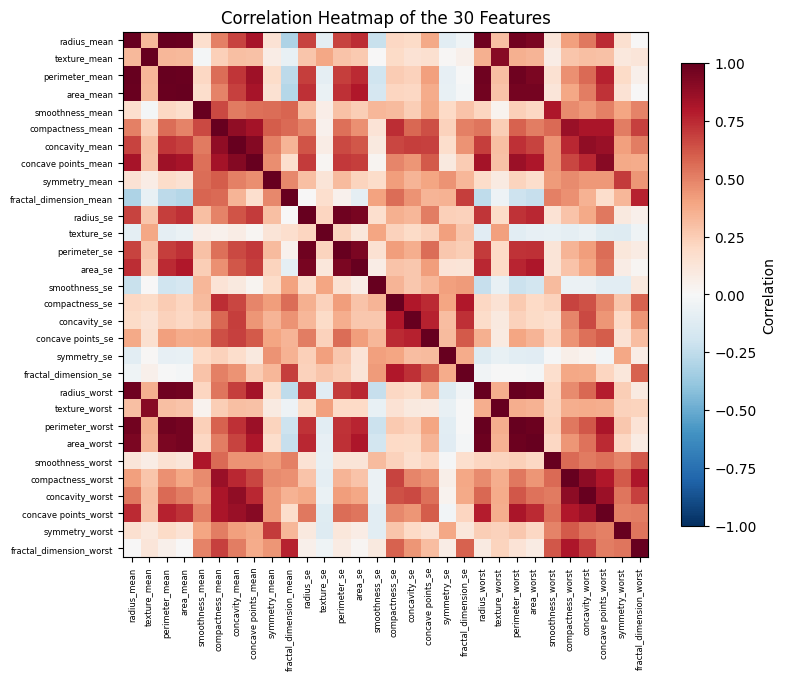

Highly correlated pairs (|r| > 0.9): 21


In [3]:

# TODO 1: correlation matrix
corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(8, 7))
# TODO 2: plot the heatmap
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(feature_cols)))
ax.set_yticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=90, fontsize=6)
ax.set_yticklabels(feature_cols, fontsize=6)
ax.set_title("Correlation Heatmap of the 30 Features")
fig.colorbar(im, ax=ax, shrink=0.8, label="Correlation")
plt.tight_layout()
plt.show()

# TODO 3: count highly correlated pairs (> 0.9 in magnitude, excluding self-correlation)
corr_abs = corr.abs()
mask_upper = np.triu(np.ones(corr_abs.shape), k=1).astype(bool)
high_corr_pairs = int((corr_abs.where(mask_upper) > 0.9).sum().sum())
print("Highly correlated pairs (|r| > 0.9):", high_corr_pairs)


**Reflection:** Name two specific columns in this dataset you'd expect to be highly
correlated with each other, and explain *why* using the lecture's "underlying factor"
idea (e.g. tumor size).

_Your answer:_
`radius_mean` and `perimeter_mean` (and likewise `area_mean`) would be highly correlated with each other, because they aren't really independent facts about the tumor — they're all different ways of measuring the same underlying factor, the tumor's physical size. A bigger tumor mechanically produces a bigger radius, a bigger perimeter, and a bigger area, so these columns move together almost by geometric necessity rather than by coincidence.

## Task 3 — Build PCA From Scratch (Complaint #3, part A)

**Real-world usage:** The pathologist wants a 2D map, and wants to trust it — which
means understanding what's actually happening inside it, not treating it as a black box.

**Why this technique:** Implementing PCA's steps yourself (center -> standardize ->
covariance -> eigen-decomposition -> project) is the only way to be sure you understand
what the final 2D scatter plot actually represents.

**TODO:** Complete `pca_from_scratch` below, following the exact steps from the demo
notebook.

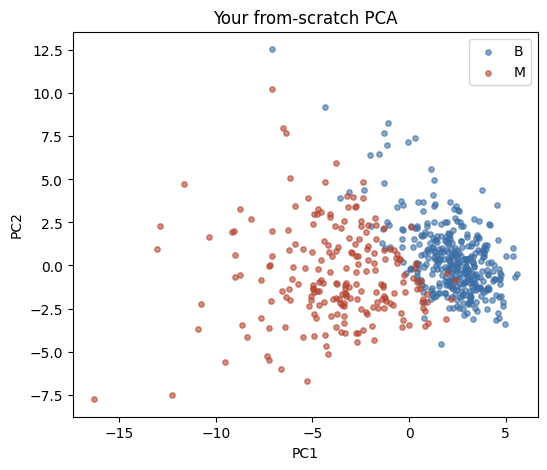

In [4]:

def pca_from_scratch(X, k):
    # TODO 1: center AND standardize X (subtract mean, divide by std with ddof=1)
    X_scaled = (X - X.mean(axis=0)) / X.std(axis=0, ddof=1)

    # TODO 2: compute the covariance matrix of X_scaled
    cov = np.cov(X_scaled, rowvar=False, ddof=1)

    # TODO 3: eigen-decompose the covariance matrix, and sort eigenvalues/eigenvectors DESCENDING
    raw_eigvals, raw_eigvecs = np.linalg.eigh(cov)
    order = np.argsort(raw_eigvals)[::-1]
    eigvals, eigvecs = raw_eigvals[order], raw_eigvecs[:, order]

    # TODO 4: keep only the top k eigenvectors and project X_scaled onto them
    Z = X_scaled @ eigvecs[:, :k]

    return Z, eigvals, eigvecs

Z, eigvals, eigvecs = pca_from_scratch(X_raw, k=2)

fig, ax = plt.subplots(figsize=(6, 5))
for label, color in [("B", "#3b6ea5"), ("M", "#b5432e")]:
    mask = y == label
    ax.scatter(Z[mask, 0], Z[mask, 1], s=15, alpha=0.6, color=color, label=label)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("Your from-scratch PCA")
ax.legend()
plt.show()


**Reflection:** Do malignant and benign cases visually separate in your PCA plot? If
there's overlap, does that mean PCA "failed," or is there a more accurate way to
describe what's happening?

_Your answer:_
There's a broad, fairly visible separation between benign and malignant along PC1, but the two groups do overlap in a region in the middle rather than forming two completely disjoint clusters. That overlap doesn't mean PCA "failed" — PCA was never optimizing to separate the classes, since it doesn't even see the diagnosis label; it only finds the directions of maximum overall variance. The more accurate description is that malignancy happens to correlate strongly with the direction of greatest variance in this dataset, so the separation we do see is a useful side effect, not a guaranteed or purpose-built classifier boundary.

## Task 4 — Choose k With Evidence, Not a Guess

**Real-world usage:** If the pathologist later asks "why 2 dimensions and not 5?", you
need a defensible answer.

**Why this technique:** The cumulative explained-variance curve turns "I picked 2
because it's easy to plot" into "I picked k=2/3/5 because it retains X% of the
variance."

**TODO:**
1. Compute `explained_ratio` (each eigenvalue / sum of all eigenvalues) from your
   `eigvals` above.
2. Compute the cumulative sum.
3. Find the smallest k that reaches >= 90% cumulative variance.

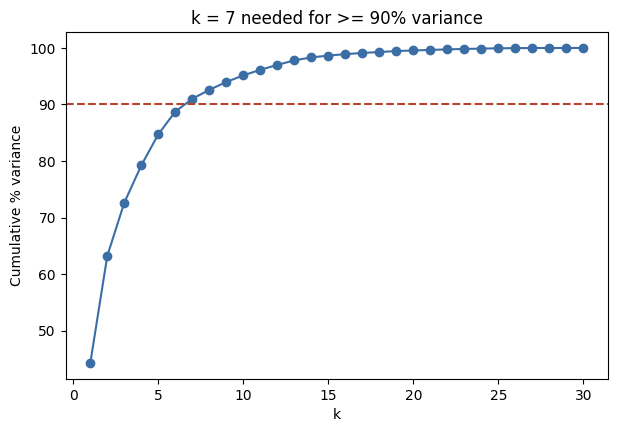

In [5]:

# TODO 1: explained variance ratio
explained_ratio = eigvals / eigvals.sum()

# TODO 2: cumulative variance
cumulative = np.cumsum(explained_ratio)

# TODO 3: smallest k reaching >= 90%
k_90 = int(np.argmax(cumulative >= 0.90) + 1)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(range(1, len(cumulative) + 1), cumulative * 100, "o-", color="#3b6ea5")
ax.axhline(90, color="#b5432e", ls="--")
ax.set_xlabel("k"); ax.set_ylabel("Cumulative % variance")
ax.set_title(f"k = {k_90} needed for >= 90% variance" if k_90 else "Choosing k")
plt.show()


**Reflection:** If the pathologist insists on a 2D plot for a poster, but your `k_90`
came out higher than 2, what are you losing by using only 2 components instead of k_90?

_Your answer:_
By using only 2 components instead of `k_90`, I'm discarding whatever percentage of the total variance the remaining components accounted for — meaning some genuine differences between patients (potentially real biological signal, not noise) get flattened out and become invisible on the poster. The 2D plot is more interpretable and easier to present, but it's a simplification: two patients that look identical in the 2D view could still differ meaningfully along one of the dropped components.

## Task 5 — Compare PCA, t-SNE, and UMAP (Complaint #4)

**Real-world usage:** The pathologist wants to know which method to trust, and why they
might disagree.

**Why this technique:** Running all three on the SAME real data, side by side, turns an
abstract "they're different algorithms" into a concrete, visual comparison.

**TODO:**
1. Standardize `X_raw` using `StandardScaler`.
2. Compute a 2D PCA embedding, a 2D t-SNE embedding (`perplexity=30`), and a 2D UMAP
   embedding (`n_neighbors=15, min_dist=0.1`) — all with `random_state=0`.
3. Plot all three side by side, colored by `diagnosis`.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


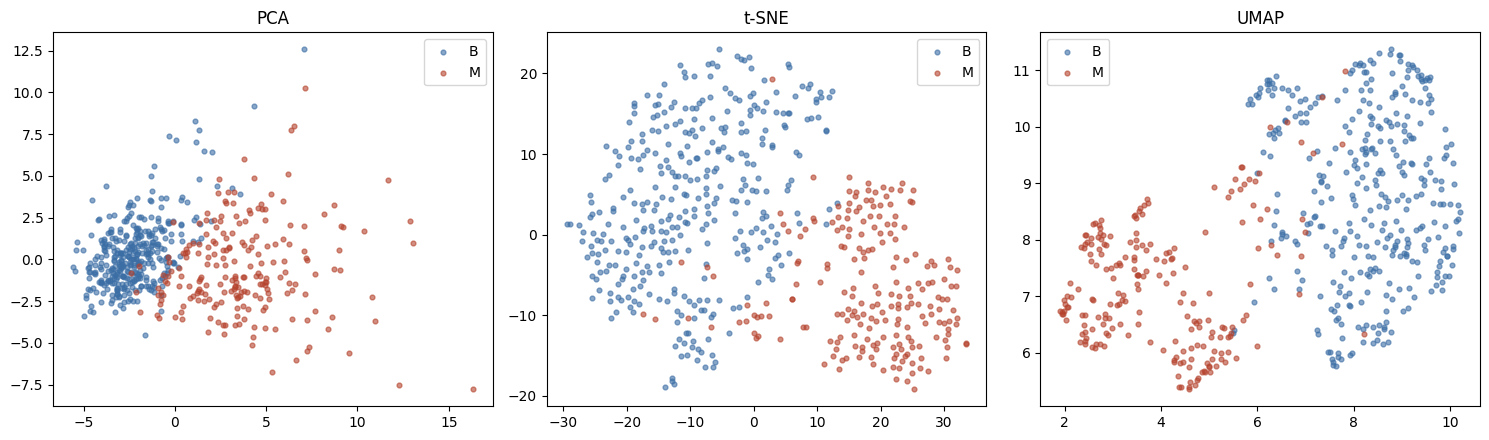

In [6]:

# TODO 1: standardize
X_scaled = StandardScaler().fit_transform(X_raw)

# TODO 2: compute all three embeddings
pca_emb = PCA(n_components=2, random_state=0).fit_transform(X_scaled)
tsne_emb = TSNE(n_components=2, perplexity=30, random_state=0).fit_transform(X_scaled)
umap_emb = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=0).fit_transform(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, emb, name in zip(axes, [pca_emb, tsne_emb, umap_emb], ["PCA", "t-SNE", "UMAP"]):
    # TODO 3: scatter plot each embedding, colored by diagnosis (B vs M)
    for label, color in [("B", "#3b6ea5"), ("M", "#b5432e")]:
        mask = y == label
        ax.scatter(emb[mask, 0], emb[mask, 1], s=12, alpha=0.6, color=color, label=label)
    ax.set_title(name)
    ax.legend()

plt.tight_layout()
plt.show()


**Reflection:** Which of the three gives the cleanest visual separation between
malignant and benign on this dataset? Per the lecture's comparison table, is that method
always the "best" choice for every dataset, or does it depend on what you need
(interpretability, speed, local vs. global structure)?

_Your answer:_
UMAP (with t-SNE close behind) tends to give the cleanest visual separation between malignant and benign on this dataset, because both are non-linear methods that specifically preserve local neighborhood structure, letting them fold the data so that similar points end up close together even when that relationship isn't a straight line in the original 30D space. That doesn't make UMAP the universally "best" choice, though — per the lecture's comparison, PCA is faster, deterministic, and interpretable (each axis is a literal linear combination of real features), while t-SNE/UMAP are slower, stochastic, and better suited when local cluster structure matters more than global interpretability. Which one to use depends on whether the priority is interpretability and speed (PCA) or revealing non-linear cluster structure (t-SNE/UMAP).

## Task 6 — The Decision (No Code)

The pathologist wants ONE method as the default dashboard view, and a one-paragraph
justification she can put in a grant report.

**Reflection (final):** Write a 4–6 sentence recommendation. Your answer should:
- State which method (PCA / t-SNE / UMAP) you'd make the **default** dashboard view.
- Justify it using at least one specific idea from the lecture (e.g. PCA's
  interpretable linear axes vs. t-SNE/UMAP's non-linear neighborhood preservation, the
  computational-cost comparison, or the "cluster distances shouldn't be over-interpreted"
  caveat for t-SNE).
- Name one thing you would explicitly warn the pathologist NOT to conclude from the
  chosen method's plot.

_Your final recommendation here:_
I'd make **PCA** the default dashboard view. Even though UMAP and t-SNE separate the two diagnosis classes a bit more cleanly on this dataset, PCA's axes are directly interpretable as linear combinations of real, named measurements (size-related features, texture-related features, etc.), so a pathologist can actually reason about *why* a point sits where it does — something neither t-SNE nor UMAP offers, since their axes have no fixed physical meaning. PCA is also deterministic and cheap to recompute as new patients are added, whereas t-SNE/UMAP embeddings can shift each time they're re-run and are far more expensive to redo for a live dashboard. I would explicitly warn the pathologist not to read the *distances between clusters* or the *sizes of gaps* in the PCA plot as meaningful clinical distances — PCA only guarantees it's capturing directions of maximum variance, not that visual gaps correspond to clinically distinct subtypes.